In [ ]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

positive_reviews = [
    "The car engine is very smooth and powerful",
    "Excellent mileage and comfortable seats",
    "The braking system works perfectly",
    "Very good driving experience",
    "Amazing pickup and low fuel consumption",
    "The suspension is comfortable on rough roads",
    "The steering feels light and responsive",
    "Very satisfied with the vehicle performance",
    "The AC cools the cabin quickly",
    "The dashboard design looks premium"
]

negative_reviews = [
    "Engine makes a loud noise while driving",
    "Very poor mileage and high fuel consumption",
    "Brake performance is disappointing",
    "Seats are uncomfortable for long drives",
    "The suspension is too hard",
    "The steering vibrates at high speed",
    "Engine overheats after long driving",
    "The battery drains very quickly",
    "Too much vibration inside the cabin",
    "Frequent maintenance problems with this car"
]

reviews = []
labels = []

for _ in range(500):
    reviews.append(random.choice(positive_reviews))
    labels.append(1)

for _ in range(500):
    reviews.append(random.choice(negative_reviews))
    labels.append(0)

combined = list(zip(reviews, labels))
random.shuffle(combined)

reviews, labels = zip(*combined)

In [ ]:
feedback_df = pd.DataFrame({
    "Review": reviews,
    "Sentiment": labels
})

feedback_df.head()

,Review,Sentiment
0,The suspension is too hard,0
1,Frequent maintenance problems with this car,0
2,The dashboard design looks premium,1
3,Brake performance is disappointing,0
4,The battery drains very quickly,0


In [ ]:
print("Dataset Shape:", feedback_df.shape)
print(feedback_df["Sentiment"].value_counts())

Dataset Shape: (1000, 2)
Sentiment
0    500
1    500
Name: count, dtype: int64


In [ ]:
VOCAB_SIZE = 2000
MAX_LENGTH = 20

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(feedback_df["Review"])

sequences = tokenizer.texts_to_sequences(feedback_df["Review"])

padded_reviews = pad_sequences(
    sequences,
    maxlen=MAX_LENGTH,
    padding="post"
)

X_train, X_test, y_train, y_test = train_test_split(
    padded_reviews,
    feedback_df["Sentiment"],
    test_size=0.20,
    random_state=42,
    stratify=feedback_df["Sentiment"]
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (800, 20)
Testing Samples: (200, 20)


In [ ]:
model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=32, input_length=MAX_LENGTH),

    LSTM(64),

    Dropout(0.3),

    Dense(32, activation="relu"),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.4969 - loss: 0.6935 - val_accuracy: 0.5188 - val_loss: 0.6906
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7688 - loss: 0.6633 - val_accuracy: 1.0000 - val_loss: 0.4685
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.1112 - val_accuracy: 1.0000 - val_loss: 0.0028
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 5.2910e-04
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 5.3146e-04 - val_accuracy: 1.0000 - val_loss: 3.3761e-04
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 4.5106e-04 - val_accuracy: 1.0000 - val_loss: 2.6693e-04
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 1.0000 - loss: 3.6633e-04 - val_accuracy: 1.0000 - val_loss: 2.2063e-04
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 3.045

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Test Accuracy:", round(accuracy,3))
print("Test Loss:", round(loss,3))

Test Accuracy: 1.0
Test Loss: 0.0


In [ ]:
predictions = model.predict(X_test, verbose=0)

predicted_labels = (predictions > 0.5).astype(int).flatten()

print(classification_report(
    y_test,
    predicted_labels,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       100
    Positive       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



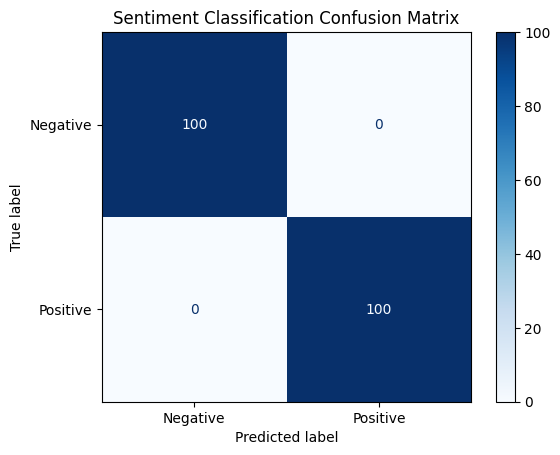

In [ ]:
cm = confusion_matrix(y_test, predicted_labels)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
).plot(cmap="Blues")

plt.title("Sentiment Classification Confusion Matrix")
plt.show()

In [ ]:
new_reviews = [
    "The engine performance is excellent and mileage is very good",
    "The battery drains quickly and the engine overheats",
    "Comfortable seats and smooth steering",
    "Very poor braking and high maintenance cost"
]

new_seq = tokenizer.texts_to_sequences(new_reviews)
new_pad = pad_sequences(new_seq, maxlen=MAX_LENGTH, padding="post")

results = model.predict(new_pad, verbose=0)

for review, score in zip(new_reviews, results):
    sentiment = "Positive" if score > 0.5 else "Negative"
    print("Review:", review)
    print("Predicted Sentiment:", sentiment)
    print("Confidence:", round(float(score),3))
    print("-"*50)

Review: The engine performance is excellent and mileage is very good
Predicted Sentiment: Positive
Confidence: 1.0
--------------------------------------------------
Review: The battery drains quickly and the engine overheats
Predicted Sentiment: Negative
Confidence: 0.0
--------------------------------------------------
Review: Comfortable seats and smooth steering
Predicted Sentiment: Positive
Confidence: 1.0
--------------------------------------------------
Review: Very poor braking and high maintenance cost
Predicted Sentiment: Negative
Confidence: 0.0
--------------------------------------------------


/tmp/ipykernel_624/423534282.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Confidence:", round(float(score),3))


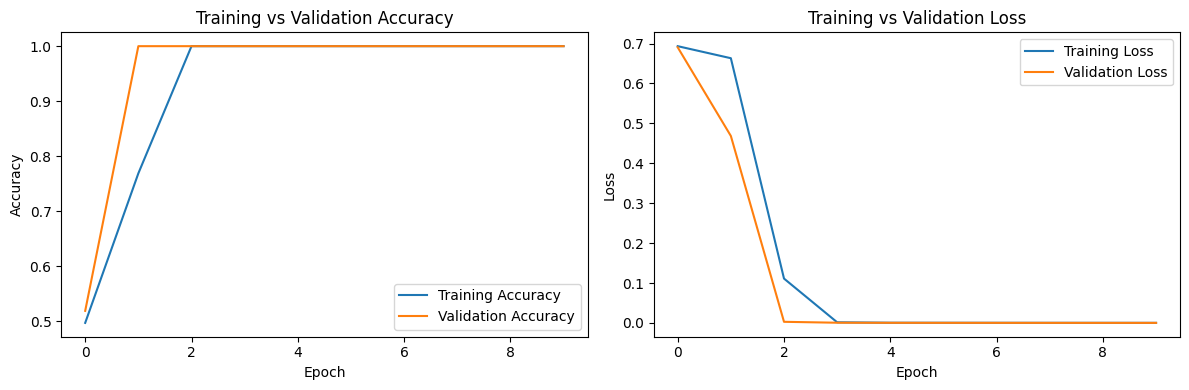

In [ ]:
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()